<a href="https://colab.research.google.com/github/Shatibiy001/Adeleke-Uthman-/blob/main/student_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   id first_name last_name                                  email  gender  \
0   1       Paul     Casey         paul.casey.1@gslingacademy.com    male   
1   2   Danielle  Sandoval  danielle.sandoval.2@gslingacademy.com  female   
2   3       Tina   Andrews       tina.andrews.3@gslingacademy.com  female   
3   4       Tara     Clark         tara.clark.4@gslingacademy.com  female   
4   5    Anthony    Campos     anthony.campos.5@gslingacademy.com    male   

   part_time_job  absence_days  extracurricular_activities  \
0          False             3                       False   
1          False             2                       False   
2          False             9                        True   
3          False             5                       False   
4          False             5                       False   

   weekly_self_study_hours   career_aspiration  math_score  history_score  \
0                       27              Lawyer          73             81   
1         

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


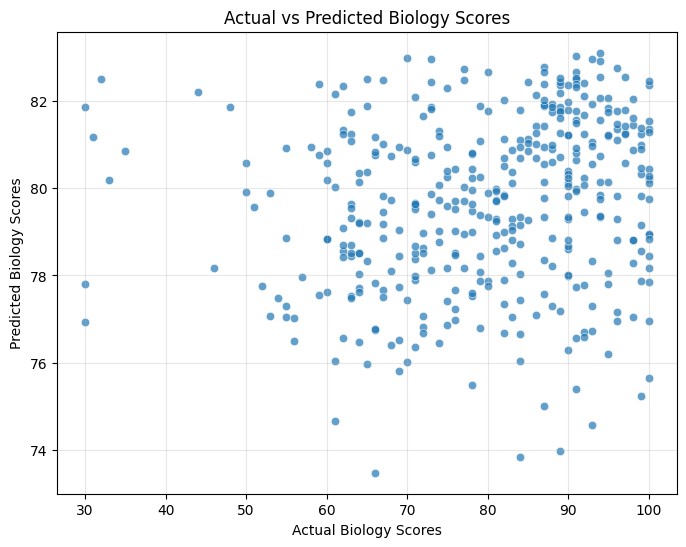

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # for nicer visuals
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("student-scores.csv")
print(df.head())
print(df.info())

X = df[["math_score", "physics_score"]]
y = df['biology_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Actual values:", list(y_test[:5]))
print("Predicted values:", list(y_pred[:5]))

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

new_students = [[70, 75], [85, 90], [50, 60]]  # [math_score, physics_score] - corrected comment
new_predictions = model.predict(new_students)

for scores, pred in zip(new_students, new_predictions):
    print(f"Math={scores[0]}, Physics={scores[1]} → Predicted Biology = {pred:.2f}") # corrected print statement


plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Biology Scores") # corrected label
plt.ylabel("Predicted Biology Scores") # corrected label
plt.title("Actual vs Predicted Biology Scores") # corrected title
plt.grid(True, alpha=0.3)
plt.show()